# Project 2: Data Classification Using AI

## Objective
The objective of this project is to build a basic classification model using a small dataset. The project demonstrates the fundamental supervised machine learning workflow, including data loading, preprocessing, training, testing, and evaluation.



## Import Required Libaraies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay

## Loud Dataset

In [3]:
iris = load_iris()

In [4]:
X = iris.data
y = iris.target

In [5]:
irisDf = pd.DataFrame(X, columns= iris.feature_names)

In [6]:
irisDf['species'] = y

In [7]:
spacies_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
irisDf['species_name'] = irisDf['species'].map(spacies_mapping)

In [8]:
irisDf.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Dataset Information

In [9]:
print(irisDf.shape)
print(irisDf.info())
print(irisDf.describe())

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000    

I have no null values, the dataTypes seem to be in the right context for each attribute

### Check Target Classes

In [10]:
print(irisDf['species_name'].value_counts())

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


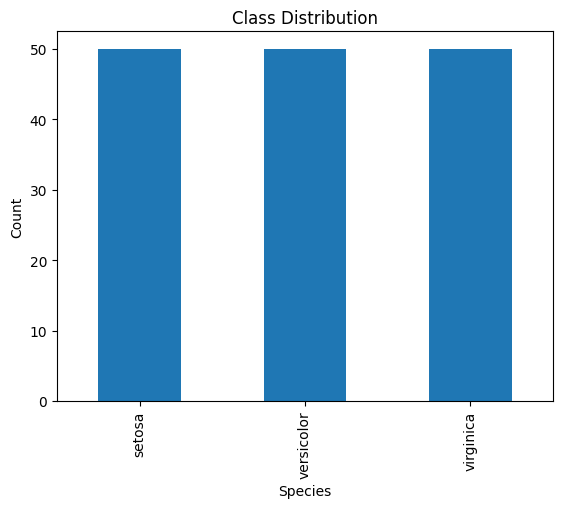

In [11]:
irisDf['species_name'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

## Separate Features and Target

In [12]:
X = irisDf.drop(['species','species_name'], axis =1)
y = irisDf['species']

## Split the Dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Feature Scaling

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**why scaling**

KNN relies on distance calculations. Scaling ensures all features contribute equally to the distance measurement.

## Build the KNN Model

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)

In [16]:
# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [17]:
# Make Predictions
y_pred = knn.predict(X_test)
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


## Evaluate the Model

### Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9333333333333333


### Confusion Matrix

In [19]:
f1 = f1_score(y_test,y_pred, average='weighted')
print("F1 Score: ",f1)

F1 Score:  0.9326599326599326


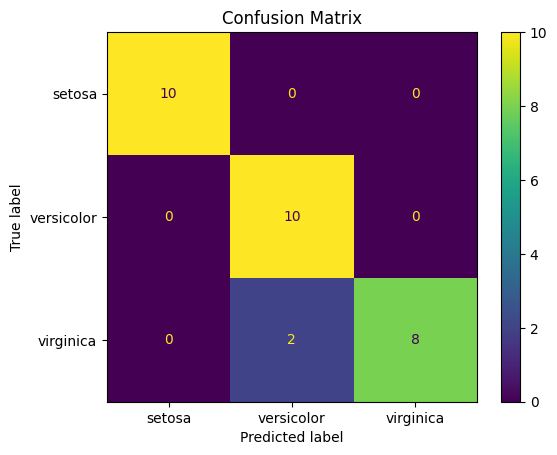

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels= iris.target_names)
plt.title("Confusion Matrix")
plt.show()

### Classification Report

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## Experiment with Different K Values

In [22]:
results = []

for k in range(1,16):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predications = model.predict(X_test)

    accuracy = accuracy_score(y_test, predications)

    results.append([k, accuracy])

results_df = pd.DataFrame(results, columns=['K', 'Accuracy'])
print(results_df)

     K  Accuracy
0    1  0.966667
1    2  0.933333
2    3  0.933333
3    4  0.933333
4    5  0.933333
5    6  0.933333
6    7  0.966667
7    8  0.933333
8    9  0.966667
9   10  0.966667
10  11  0.966667
11  12  0.966667
12  13  0.966667
13  14  0.966667
14  15  0.966667


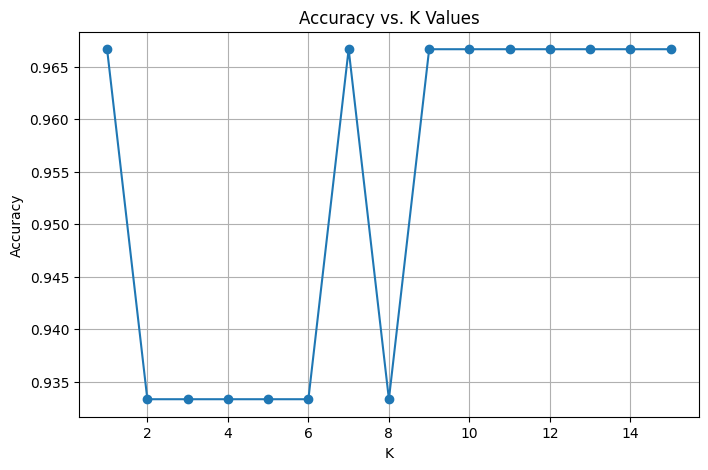

In [23]:
plt.figure(figsize=(8,5))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o')
plt.title('Accuracy vs. K Values')
plt.xlabel('K')
plt.ylabel('Accuracy')

plt.grid(True)
plt.show()

## Results
The KNN model successfully classified Iris flower species using their measurements.

**Model Performance**


*   Accuracy Score: 93.33%
*   Weighted F1 Score: 93.27%

**Classification Report Summary**



```
    Spacies  |  Precision  |  Recall  |  F1-Score
 ------------------------------------------------
 Setosa      |     1.00    |    1.00  |   1.00
 ------------------------------------------------
 Versicolor  |     0.83    |    1.00  |   0.91
 ------------------------------------------------
 Virginica   |     1.00    |    0.80  |   0.89

```
The model correctly classified most flower samples. Setosa achieved perfect classification, while a small number of Virginica samples were misclassified, resulting in a slightly lower recall score.

**K Value Experiment**

Different K values were tested from 1 to 15.
The highest observed accuracy was **96.67%**, achieved by several K values including:

* K = 1
* K = 7
* K = 9
* K = 10
* K = 11
* K = 12
* K = 13
* K = 14
* K = 15

This demonstrates that the iris dataset is highly suitable for KNN classification.





# Conclusion
This project demonstrated the complete supervised ML workflow using the Iris Dataset. The data was explored, preprocessed, scaled, and divided into training and testing subsets before applying the K-Nearest Neeighbors (KNN) classification algorithm.

The trained model achieved an accuracy of 93.33% and a weighted F1-Score of 93.67%, indicating strong predictive performance. Additional Experimentation with different K values showed that the model could achieve up to 96.67% accuracy, highlighting the importance of hyperparameter selection.

Overall, the project successfully met the objectives of loading a dataset, appling a classification algorithm, training a model, and evaluating its performance using multiple metrices.